# Exploración de `data` y `user` juntos

Este notebook cruza la tabla de calificaciones (`data`) con la tabla demográfica (`user`) para
responder una sola pregunta general: **¿las características de los usuarios se relacionan con la forma en
que califican?**

Se distinguen dos aspectos que suelen confundirse:

* **cuánto** califica cada grupo (actividad, número de calificaciones);
* **qué tan alto** califica cada grupo (nivel de la calificación).

No se usa información de las películas (`item`): eso corresponde a los notebooks `data_item.ipynb` y
`data_item_user.ipynb` de otros integrantes.

## 1. Importación de librerías y datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo común para todas las figuras del notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
# Se cargan las dos tablas por separado para poder identificar las claves y validar el merge.
data = pd.read_csv("../../data/processed/data.csv", parse_dates=["datetime"])
user = pd.read_csv("../../data/processed/user.csv", dtype={"zip_code": str})

print(f"data: {data.shape[0]} filas, {data.shape[1]} columnas -> {list(data.columns)}")
print(f"user: {user.shape[0]} filas, {user.shape[1]} columnas -> {list(user.columns)}")
data.head()

data: 99455 filas, 5 columnas -> ['user_id', 'item_id', 'rating', 'timestamp', 'datetime']
user: 943 filas, 5 columnas -> ['user_id', 'age', 'gender', 'occupation', 'zip_code']


,user_id,item_id,rating,timestamp,datetime
0,1,1,5,874965758,1997-09-22 22:02:38
1,1,2,3,876893171,1997-10-15 05:26:11
2,1,3,4,878542960,1997-11-03 07:42:40
3,1,4,3,876893119,1997-10-15 05:25:19
4,1,5,3,889751712,1998-03-13 01:15:12


## 2. Identificación de claves y relación entre las tablas

**Qué se calcula:** qué columna comparten las dos tablas, si esa columna es única en cada una, si hay
valores nulos en ella y si existen registros huérfanos en cualquiera de los dos sentidos.

**Por qué es relevante:** determina el tipo de `join` correcto. Si `user_id` no fuera único en `user`, el
merge multiplicaría filas de calificaciones; si hubiera huérfanos, `inner` y `left` darían resultados
distintos y habría que elegir con criterio.

In [3]:
columnas_comunes = sorted(set(data.columns) & set(user.columns))
print(f"Columnas presentes en ambas tablas: {columnas_comunes}")
print(f"Tipo de user_id -> data: {data['user_id'].dtype}, user: {user['user_id'].dtype}")
print(f"Nulos en la clave -> data: {data['user_id'].isnull().sum()}, user: {user['user_id'].isnull().sum()}\n")

print(f"user_id único en 'user': {user['user_id'].is_unique}"
      f" ({user['user_id'].nunique()} valores para {user.shape[0]} filas)")
print(f"user_id único en 'data': {data['user_id'].is_unique}"
      f" ({data['user_id'].nunique()} valores para {data.shape[0]} filas)")
print("-> la relación es 1:N (un usuario, muchas calificaciones)\n")

sin_demografia = ~data["user_id"].isin(user["user_id"])
sin_calificaciones = ~user["user_id"].isin(data["user_id"])
print(f"Calificaciones cuyo usuario no existe en 'user': {sin_demografia.sum()}")
print(f"Usuarios sin ninguna calificación en 'data': {sin_calificaciones.sum()}")

Columnas presentes en ambas tablas: ['user_id']
Tipo de user_id -> data: int64, user: int64
Nulos en la clave -> data: 0, user: 0

user_id único en 'user': True (943 valores para 943 filas)
user_id único en 'data': False (943 valores para 99455 filas)
-> la relación es 1:N (un usuario, muchas calificaciones)

Calificaciones cuyo usuario no existe en 'user': 0
Usuarios sin ninguna calificación en 'data': 0


**Resultados:** la única columna compartida es `user_id`, entera y sin nulos en ambas tablas. Es
única en `user` (943 valores para 943 filas) y repetida en `data` (943 valores para 99 455 filas), lo que
confirma una relación **1:N**. No hay calificaciones huérfanas ni usuarios sin calificaciones.

**Conclusión:** al no existir huérfanos en ninguno de los dos sentidos, `inner`, `left` y `right`
producen exactamente el mismo resultado. Se usa **`inner`** por ser el más explícito: deja constancia de
que solo interesan las filas con correspondencia en ambas tablas, y al no perder ninguna se comprueba que
la integridad referencial es completa.

## 3. Merge y validación

**Qué se calcula:** el cruce `data ⋈ user` por `user_id` y cinco comprobaciones posteriores: número de
filas, número de usuarios distintos, nulos introducidos, duplicación de pares usuario-película y
equivalencia con el archivo `data_user.csv` que el equipo ya exportó.

**Por qué es relevante:** un merge mal hecho sobre una relación 1:N infla las filas en silencio y todos
los promedios posteriores quedan sesgados. Validar es obligatorio, no opcional.

In [4]:
data_user = data.merge(user, on="user_id", how="inner")

print("Validaciones del merge")
print(f"  filas antes (data): {data.shape[0]} | filas después: {data_user.shape[0]}"
      f" | ¿se conservan todas?: {data_user.shape[0] == data.shape[0]}")
print(f"  usuarios distintos antes: {data['user_id'].nunique()} | después: {data_user['user_id'].nunique()}")
print(f"  columnas: {data.shape[1]} + {user.shape[1]} - 1 (clave) = {data_user.shape[1]}")
print(f"  valores nulos introducidos: {data_user.isnull().sum().sum()}")
print(f"  pares (user_id, item_id) duplicados: {data_user.duplicated(subset=['user_id', 'item_id']).sum()}")

# Coherencia con el archivo ya exportado por el equipo
data_user_equipo = pd.read_csv("../../data/processed/data_user.csv",
                               parse_dates=["datetime"], dtype={"zip_code": str})
iguales = (
    data_user.sort_values(["user_id", "item_id"]).reset_index(drop=True)
    .equals(data_user_equipo.sort_values(["user_id", "item_id"]).reset_index(drop=True))
)
print(f"  el merge reproduce exactamente data/processed/data_user.csv: {iguales}")

data_user.head()

Validaciones del merge
  filas antes (data): 99455 | filas después: 99455 | ¿se conservan todas?: True
  usuarios distintos antes: 943 | después: 943
  columnas: 5 + 5 - 1 (clave) = 9
  valores nulos introducidos: 0
  pares (user_id, item_id) duplicados: 0
  el merge reproduce exactamente data/processed/data_user.csv: True


,user_id,item_id,rating,timestamp,datetime,age,gender,occupation,zip_code
0,1,1,5,874965758,1997-09-22 22:02:38,24,M,technician,85711
1,1,2,3,876893171,1997-10-15 05:26:11,24,M,technician,85711
2,1,3,4,878542960,1997-11-03 07:42:40,24,M,technician,85711
3,1,4,3,876893119,1997-10-15 05:25:19,24,M,technician,85711
4,1,5,3,889751712,1998-03-13 01:15:12,24,M,technician,85711


**Resultados:** 99 455 filas antes y después, los mismos 943 usuarios, 9 columnas (5 + 5 − 1), cero
nulos nuevos, cero pares usuario-película duplicados y coincidencia exacta con `data_user.csv`.

**Conclusión:** el merge es correcto. No hubo ni pérdida ni duplicación de registros, y el resultado es
consistente con el archivo que usa el resto del equipo.

## 4. Nota metodológica: unidad de análisis

Esta es la decisión más importante del notebook.

La tabla cruzada tiene **99 455 filas pero solo 943 sujetos**. Las calificaciones de un mismo usuario no
son independientes entre sí: quien califica 734 películas pesa 38 veces más que quien califica 19, y
comparte con todas sus filas la misma edad, género y ocupación. Aplicar una prueba estadística sobre las
99 455 filas trataría esas repeticiones como información nueva y produciría p-valores artificialmente
pequeños (**pseudorreplicación**).

Por eso se adopta esta regla en todo el notebook:

* **Descripción** (tablas de frecuencia, porcentajes, promedios globales): a nivel de **calificación**,
  n = 99 455.
* **Inferencia** (toda prueba, correlación e intervalo de confianza): a nivel de **usuario**, n = 943,
  agregando primero cada usuario a dos indicadores: su **calificación media** y su **número de
  calificaciones**.

In [5]:
# Perfil por usuario: una fila por persona (n = 943)
perfil = (
    data_user.groupby(["user_id", "gender", "occupation", "age"], as_index=False)
    .agg(n_calificaciones=("rating", "size"), calificacion_media=("rating", "mean"))
)

BINS_EDAD = [6, 17, 24, 34, 44, 54, 73]
ETIQUETAS_EDAD = ["7-17", "18-24", "25-34", "35-44", "45-54", "55-73"]
perfil["grupo_edad"] = pd.cut(perfil["age"], bins=BINS_EDAD, labels=ETIQUETAS_EDAD)
data_user["grupo_edad"] = pd.cut(data_user["age"], bins=BINS_EDAD, labels=ETIQUETAS_EDAD)

# Diccionario donde se guardan los p-valores para corregirlos al final (sección 9)
pruebas = {}

print(f"Perfil de usuarios: {perfil.shape[0]} filas (una por usuario)")
perfil.head()

Perfil de usuarios: 943 filas (una por usuario)


,user_id,gender,occupation,age,n_calificaciones,calificacion_media,grupo_edad
0,1,M,technician,24,270,3.603704,18-24
1,2,F,other,53,60,3.750000,45-54
2,3,M,writer,23,53,2.773585,18-24
3,4,M,technician,24,24,4.333333,18-24
4,5,F,other,33,174,2.867816,25-34


### Funciones auxiliares

In [6]:
def cliffs_delta(a, b):
    """Tamaño del efecto no paramétrico. |d| < 0.147 despreciable, < 0.33 pequeño, < 0.474 mediano."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u / (len(a) * len(b)) - 1


def epsilon_cuadrado(h, k, n):
    """Tamaño del efecto para Kruskal-Wallis: proporción de la variabilidad de los rangos explicada."""
    return (h - k + 1) / (n - k)


def ic95_media(x):
    """IC del 95% para la media, basado en la t de Student."""
    x = np.asarray(x, dtype=float)
    margen = stats.sem(x) * stats.t.ppf(0.975, len(x) - 1)
    return x.mean() - margen, x.mean() + margen


def holm(p_valores):
    """Corrección de Holm-Bonferroni para comparaciones múltiples."""
    ordenados = sorted(p_valores.items(), key=lambda par: par[1])
    m = len(ordenados)
    ajustados, maximo_previo = {}, 0.0
    for i, (nombre, p) in enumerate(ordenados):
        maximo_previo = max(maximo_previo, min(1.0, (m - i) * p))
        ajustados[nombre] = maximo_previo
    return ajustados

## 5. Actividad: cuántas calificaciones aporta cada usuario

**Qué se calcula:** descriptivos y concentración del número de calificaciones por usuario.

**Por qué es relevante:** determina cuánto pesa cada persona en cualquier promedio global calculado sobre
las 99 455 filas. Si unos pocos usuarios aportan gran parte de los datos, los promedios "de la muestra"
en realidad describen sobre todo a esos usuarios.

In [7]:
actividad = perfil["n_calificaciones"]
q1, q3 = actividad.quantile([0.25, 0.75])
iqr = q3 - q1
atipicos = actividad[(actividad < q1 - 1.5 * iqr) | (actividad > q3 + 1.5 * iqr)]

print(actividad.describe().round(2), "\n")
print(f"Asimetría: {actividad.skew():.2f} | IQR: {iqr:.0f}"
      f" | usuarios atípicos (1.5*IQR): {atipicos.size} (todos por exceso de actividad)")

n_top = int(round(perfil.shape[0] * 0.10))
top_activos = actividad.sort_values(ascending=False).head(n_top)
mitad_inactiva = actividad.sort_values().head(perfil.shape[0] // 2)
print(f"\nEl 10% más activo ({n_top} usuarios) aporta el {top_activos.sum() / actividad.sum() * 100:.1f}%"
      f" de las calificaciones")
print(f"La mitad menos activa ({perfil.shape[0] // 2} usuarios) aporta el"
      f" {mitad_inactiva.sum() / actividad.sum() * 100:.1f}%")

count    943.00
mean     105.47
std      100.57
min       19.00
25%       32.00
50%       64.00
75%      147.50
max      734.00
Name: n_calificaciones, dtype: float64 

Asimetría: 1.90 | IQR: 116 | usuarios atípicos (1.5*IQR): 42 (todos por exceso de actividad)

El 10% más activo (94 usuarios) aporta el 32.0% de las calificaciones
La mitad menos activa (471 usuarios) aporta el 16.9%


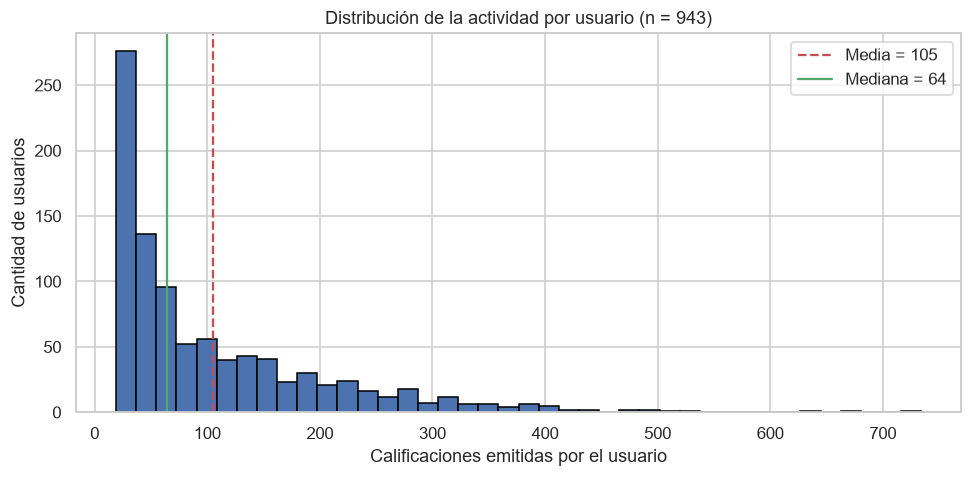

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(actividad, bins=40, color="#4C72B0", edgecolor="black")
ax.axvline(actividad.mean(), color="#C44E52", linestyle="--",
           label=f"Media = {actividad.mean():.0f}")
ax.axvline(actividad.median(), color="#55A868", linestyle="-",
           label=f"Mediana = {actividad.median():.0f}")
ax.set_xlabel("Calificaciones emitidas por el usuario")
ax.set_ylabel("Cantidad de usuarios")
ax.set_title("Distribución de la actividad por usuario (n = 943)")
ax.legend()
fig.tight_layout()
plt.show()

**Resultados:** mediana de 64 calificaciones por usuario frente a una media de 105.5 (sd 100.6,
asimetría 1.9); el rango va de 19 a 734 y hay 42 usuarios atípicos, todos por exceso. El 10 % más activo
aporta el 32.0 % de las calificaciones, mientras que la mitad menos activa aporta apenas el 16.9 %.

**Conclusión:** la actividad está **muy concentrada**. Es la justificación empírica de la regla adoptada
en la sección 4: un promedio calculado sobre las 99 455 filas está dominado por unos pocos usuarios muy
activos, mientras que el promedio calculado sobre los 943 usuarios da a cada persona el mismo peso. Los
42 atípicos **no se eliminan**: son usuarios reales y su comportamiento es justamente parte del hallazgo.

## 6. Calificaciones y género

**Qué se calcula:** distribución porcentual de las calificaciones por género (nivel calificación), medias
en ambos niveles de análisis y dos pruebas de **Mann-Whitney** sobre los 943 usuarios: una para la
calificación media y otra para el número de calificaciones.

**Pregunta que responde:** ¿hombres y mujeres califican distinto, sea en nivel o en cantidad?

**Hipótesis:** H₀: la distribución del indicador es igual en ambos géneros. H₁: difiere.

**Supuestos:** independencia entre usuarios (✓ tras agregar por usuario) y variable ordinal (✓). No se
requiere normalidad.

In [9]:
mujeres = perfil[perfil["gender"] == "F"]
hombres = perfil[perfil["gender"] == "M"]

print("Nivel calificación (n = 99 455): media por género")
print(data_user.groupby("gender")["rating"].agg(["size", "mean", "std", "median"]).round(3), "\n")

print("Nivel usuario (n = 943): media de las medias por usuario")
print(perfil.groupby("gender")[["calificacion_media", "n_calificaciones"]]
      .agg(["size", "mean", "median"]).round(3), "\n")

_, p_media_genero = stats.mannwhitneyu(mujeres["calificacion_media"],
                                       hombres["calificacion_media"], alternative="two-sided")
_, p_activ_genero = stats.mannwhitneyu(mujeres["n_calificaciones"],
                                       hombres["n_calificaciones"], alternative="two-sided")
pruebas["MW calificación media ~ género"] = p_media_genero
pruebas["MW nº calificaciones ~ género"] = p_activ_genero

print(f"Mann-Whitney calificación media ~ género: p = {p_media_genero:.4f}"
      f" | delta = {cliffs_delta(mujeres['calificacion_media'], hombres['calificacion_media']):.4f}")
print(f"Mann-Whitney nº calificaciones ~ género: p = {p_activ_genero:.4f}"
      f" | delta = {cliffs_delta(mujeres['n_calificaciones'], hombres['n_calificaciones']):.4f}")

Nivel calificación (n = 99 455): media por género
         size   mean    std  median
gender                             
F       25582  3.531  1.171     4.0
M       73873  3.529  1.109     4.0 

Nivel usuario (n = 943): media de las medias por usuario
       calificacion_media               n_calificaciones                
                     size   mean median             size     mean median
gender                                                                  
F                     273  3.587  3.623              273   93.707   54.0
M                     670  3.586  3.610              670  110.258   69.5 

Mann-Whitney calificación media ~ género: p = 0.9928 | delta = 0.0004
Mann-Whitney nº calificaciones ~ género: p = 0.0024 | delta = -0.1257


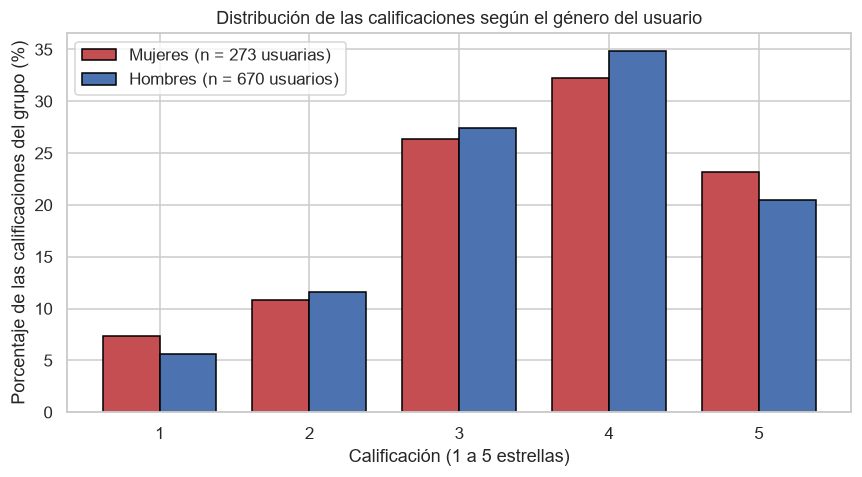

In [10]:
distribucion = pd.crosstab(data_user["gender"], data_user["rating"], normalize="index").mul(100)

fig, ax = plt.subplots(figsize=(8, 4.5))
ancho = 0.38
posiciones = np.arange(1, 6)
ax.bar(posiciones - ancho / 2, distribucion.loc["F"], ancho, color="#C44E52",
       edgecolor="black", label=f"Mujeres (n = {mujeres.shape[0]} usuarias)")
ax.bar(posiciones + ancho / 2, distribucion.loc["M"], ancho, color="#4C72B0",
       edgecolor="black", label=f"Hombres (n = {hombres.shape[0]} usuarios)")

ax.set_xticks(posiciones)
ax.set_xlabel("Calificación (1 a 5 estrellas)")
ax.set_ylabel("Porcentaje de las calificaciones del grupo (%)")
ax.set_title("Distribución de las calificaciones según el género del usuario")
ax.legend()
fig.tight_layout()
plt.show()

**Resultados:** las medias son casi idénticas: 3.531 (mujeres) frente a 3.529 (hombres) a nivel de
calificación, y 3.587 frente a 3.586 a nivel de usuario. Mann-Whitney sobre la calificación media da
**p = 0.993** con delta de Cliff ≈ 0.000. En cambio, para el número de calificaciones el resultado es
**p = 0.0024** con delta = -0.126 (efecto pequeño): la mediana de las mujeres es de 54 calificaciones
frente a 69.5 de los hombres. El gráfico muestra que las mujeres usan algo más los extremos (7.4 % de
unos frente a 5.7 %; 23.2 % de cincos frente a 20.5 %).

**Conclusión:** **el género no se relaciona con el nivel de las calificaciones, pero sí con la cantidad.**
Las mujeres de esta muestra calificaron menos películas que los hombres; el tamaño del efecto es pequeño,
así que la diferencia es real pero moderada. Diferencia estadísticamente significativa no equivale a
diferencia importante: por eso se reporta siempre el tamaño del efecto junto al p-valor.

## 7. Calificaciones y edad

**Qué se calcula:** correlación de **Spearman** entre la edad y los dos indicadores por usuario, tabla
descriptiva por grupo etario con intervalos de confianza del 95 %, y **Kruskal-Wallis** entre grupos.

**Por qué Spearman y no Pearson:** Spearman mide asociación monótona por rangos y no exige normalidad ni
linealidad; la edad es asimétrica y la calificación media está acotada entre 1 y 5.

**Hipótesis:** Spearman -> H₀: ρ = 0 (no hay asociación monótona). Kruskal-Wallis -> H₀: la distribución
del indicador es igual en los seis grupos etarios.

In [11]:
rho_media, p_rho_media = stats.spearmanr(perfil["age"], perfil["calificacion_media"])
rho_activ, p_rho_activ = stats.spearmanr(perfil["age"], perfil["n_calificaciones"])
pruebas["Spearman edad ~ calificación media"] = p_rho_media
pruebas["Spearman edad ~ nº calificaciones"] = p_rho_activ

print(f"Spearman edad ~ calificación media: rho = {rho_media:.3f} | p = {p_rho_media:.4f}")
print(f"Spearman edad ~ nº calificaciones : rho = {rho_activ:.3f} | p = {p_rho_activ:.4f}\n")

resumen_edad = perfil.groupby("grupo_edad", observed=True).agg(
    usuarios=("user_id", "size"),
    media=("calificacion_media", "mean"),
    desv_est=("calificacion_media", "std"),
    mediana_calificaciones=("n_calificaciones", "median"),
)
resumen_edad["calificaciones"] = data_user.groupby("grupo_edad", observed=True).size()
resumen_edad[["ic_inferior", "ic_superior"]] = pd.DataFrame(
    [ic95_media(perfil.loc[perfil["grupo_edad"] == g, "calificacion_media"]) for g in resumen_edad.index],
    index=resumen_edad.index,
)
print(resumen_edad.round(3))

Spearman edad ~ calificación media: rho = 0.091 | p = 0.0054
Spearman edad ~ nº calificaciones : rho = -0.117 | p = 0.0003

            usuarios  media  desv_est  mediana_calificaciones  calificaciones  \
grupo_edad                                                                      
7-17              36  3.445     0.562                    43.0            2465   
18-24            198  3.574     0.444                    80.5           23908   
25-34            310  3.548     0.442                    80.0           35267   
35-44            194  3.613     0.449                    59.5           19525   
45-54            142  3.666     0.414                    48.0           12697   
55-73             63  3.640     0.415                    51.0            5593   

            ic_inferior  ic_superior  
grupo_edad                            
7-17              3.255        3.635  
18-24             3.512        3.636  
25-34             3.498        3.597  
35-44             3.549        3

In [12]:
grupos_media = [perfil.loc[perfil["grupo_edad"] == g, "calificacion_media"].values
                for g in ETIQUETAS_EDAD]
grupos_activ = [perfil.loc[perfil["grupo_edad"] == g, "n_calificaciones"].values
                for g in ETIQUETAS_EDAD]

h_media, p_kw_media = stats.kruskal(*grupos_media)
h_activ, p_kw_activ = stats.kruskal(*grupos_activ)
pruebas["KW calificación media ~ grupo de edad"] = p_kw_media
pruebas["KW nº calificaciones ~ grupo de edad"] = p_kw_activ

k, n = len(grupos_media), perfil.shape[0]
print(f"Kruskal-Wallis calificación media ~ grupo de edad: H = {h_media:.2f} | p = {p_kw_media:.4f}"
      f" | epsilon^2 = {epsilon_cuadrado(h_media, k, n):.4f}")
print(f"Kruskal-Wallis nº calificaciones ~ grupo de edad: H = {h_activ:.2f} | p = {p_kw_activ:.4f}"
      f" | epsilon^2 = {epsilon_cuadrado(h_activ, k, n):.4f}")

Kruskal-Wallis calificación media ~ grupo de edad: H = 11.81 | p = 0.0374 | epsilon^2 = 0.0073
Kruskal-Wallis nº calificaciones ~ grupo de edad: H = 26.85 | p = 0.0001 | epsilon^2 = 0.0233


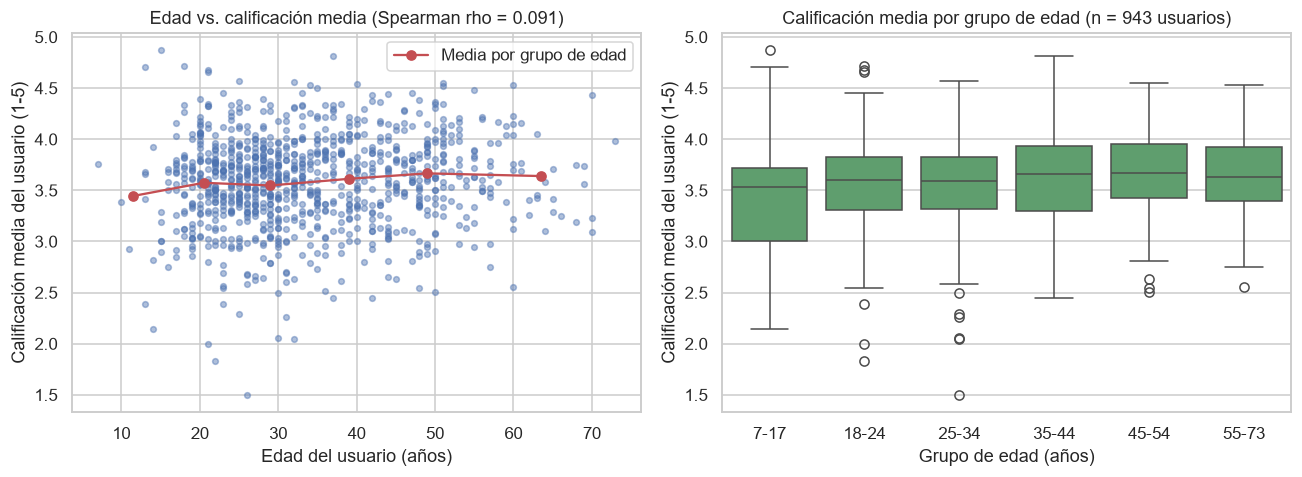

In [13]:
fig, (ax_disp, ax_caja) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_disp.scatter(perfil["age"], perfil["calificacion_media"], s=14, alpha=0.45, color="#4C72B0")
medias_grupo = perfil.groupby("grupo_edad", observed=True)["calificacion_media"].mean()
centros = [(BINS_EDAD[i] + BINS_EDAD[i + 1]) / 2 for i in range(len(ETIQUETAS_EDAD))]
ax_disp.plot(centros, medias_grupo.values, color="#C44E52", marker="o",
             label="Media por grupo de edad")
ax_disp.set_xlabel("Edad del usuario (años)")
ax_disp.set_ylabel("Calificación media del usuario (1-5)")
ax_disp.set_title(f"Edad vs. calificación media (Spearman rho = {rho_media:.3f})")
ax_disp.legend()

sns.boxplot(data=perfil, x="grupo_edad", y="calificacion_media", order=ETIQUETAS_EDAD,
            color="#55A868", ax=ax_caja)
ax_caja.set_xlabel("Grupo de edad (años)")
ax_caja.set_ylabel("Calificación media del usuario (1-5)")
ax_caja.set_title("Calificación media por grupo de edad (n = 943 usuarios)")

fig.tight_layout()
plt.show()

**Resultados:** la correlación entre edad y calificación media es **ρ = 0.091** (p = 0.005) y entre
edad y número de calificaciones **ρ = -0.117** (p = 0.0003). Por grupos, la media sube de 3.445 (7-17
años, IC [3.26, 3.64]) a 3.666 (45-54, IC [3.60, 3.73]), y Kruskal-Wallis da p = 0.037 con ε² = 0.007
para el nivel de calificación, frente a p = 0.0001 con ε² = 0.023 para la actividad.

**Conclusión:** ambas asociaciones son **muy débiles**. Un ρ de 0.09 significa que la edad explica menos
del 1 % de la variación de la calificación media; el ε² de 0.007 dice lo mismo desde la comparación de
grupos. Existe una tendencia ordenada —los usuarios mayores califican algo más alto y algo menos seguido—
pero su magnitud es tan pequeña que **no permite predecir el comportamiento de un usuario a partir de su
edad**. Además, el grupo 7-17 tiene solo 36 usuarios, de ahí que su intervalo de confianza sea el más
ancho de la tabla. Correlación no implica causalidad: la edad podría estar actuando como sustituto de
otras variables (ocupación, tiempo disponible, tipo de películas vistas) que aquí no se controlan.

## 8. Calificaciones y ocupación

**Qué se calcula:** tabla por ocupación con número de usuarios, calificaciones, media e IC 95 %, y
**Kruskal-Wallis** sobre las ocupaciones con al menos 20 usuarios.

**Por qué el filtro n ≥ 20:** con 7 u 8 usuarios, la media de una ocupación tiene un intervalo de
confianza tan ancho que cualquier ordenamiento sería ruido. Se muestran igualmente en la tabla, pero se
excluyen de la prueba y se marcan en el gráfico.

In [14]:
resumen_ocupacion = perfil.groupby("occupation").agg(
    usuarios=("user_id", "size"),
    media=("calificacion_media", "mean"),
    desv_est=("calificacion_media", "std"),
    mediana_calificaciones=("n_calificaciones", "median"),
)
resumen_ocupacion["calificaciones"] = data_user.groupby("occupation").size()
resumen_ocupacion[["ic_inferior", "ic_superior"]] = pd.DataFrame(
    [ic95_media(perfil.loc[perfil["occupation"] == o, "calificacion_media"])
     for o in resumen_ocupacion.index],
    index=resumen_ocupacion.index,
)
resumen_ocupacion["amplitud_ic"] = (resumen_ocupacion["ic_superior"]
                                    - resumen_ocupacion["ic_inferior"]).round(3)
resumen_ocupacion.sort_values("media").round(3)

,usuarios,media,desv_est,mediana_calificaciones,calificaciones,ic_inferior,ic_superior,amplitud_ic
occupation,,,,,,,,
healthcare,16,3.331,0.571,120.0,2785,3.027,3.636,0.609
homemaker,7,3.334,0.225,29.0,295,3.126,3.542,0.416
entertainment,18,3.427,0.395,74.5,2077,3.231,3.624,0.393
marketing,26,3.468,0.399,32.5,1940,3.307,3.629,0.322
retired,14,3.480,0.402,58.0,1602,3.248,3.712,0.464
writer,45,3.504,0.504,78.0,5507,3.352,3.655,0.303
salesman,12,3.523,0.406,40.5,852,3.266,3.781,0.515
executive,32,3.529,0.571,70.5,3373,3.324,3.735,0.411
other,105,3.553,0.450,69.0,10593,3.466,3.640,0.174


In [15]:
ocupaciones_validas = resumen_ocupacion.index[resumen_ocupacion["usuarios"] >= 20].tolist()
excluidas = sorted(set(resumen_ocupacion.index) - set(ocupaciones_validas))
print(f"Ocupaciones analizadas ({len(ocupaciones_validas)}): {sorted(ocupaciones_validas)}")
print(f"Excluidas por n < 20 ({len(excluidas)}): {excluidas}\n")

grupos_media = [perfil.loc[perfil["occupation"] == o, "calificacion_media"].values
                for o in ocupaciones_validas]
grupos_activ = [perfil.loc[perfil["occupation"] == o, "n_calificaciones"].values
                for o in ocupaciones_validas]
n_incluidos = sum(len(g) for g in grupos_media)

h_media, p_kw_media_ocup = stats.kruskal(*grupos_media)
h_activ, p_kw_activ_ocup = stats.kruskal(*grupos_activ)
pruebas["KW calificación media ~ ocupación"] = p_kw_media_ocup
pruebas["KW nº calificaciones ~ ocupación"] = p_kw_activ_ocup

k = len(grupos_media)
print(f"Kruskal-Wallis calificación media ~ ocupación: H = {h_media:.2f} | p = {p_kw_media_ocup:.4f}"
      f" | epsilon^2 = {epsilon_cuadrado(h_media, k, n_incluidos):.4f}")
print(f"Kruskal-Wallis nº calificaciones ~ ocupación: H = {h_activ:.2f} | p = {p_kw_activ_ocup:.4f}"
      f" | epsilon^2 = {epsilon_cuadrado(h_activ, k, n_incluidos):.4f}")

Ocupaciones analizadas (13): ['administrator', 'artist', 'educator', 'engineer', 'executive', 'librarian', 'marketing', 'other', 'programmer', 'scientist', 'student', 'technician', 'writer']
Excluidas por n < 20 (8): ['doctor', 'entertainment', 'healthcare', 'homemaker', 'lawyer', 'none', 'retired', 'salesman']

Kruskal-Wallis calificación media ~ ocupación: H = 12.32 | p = 0.4203 | epsilon^2 = 0.0004
Kruskal-Wallis nº calificaciones ~ ocupación: H = 23.08 | p = 0.0270 | epsilon^2 = 0.0133


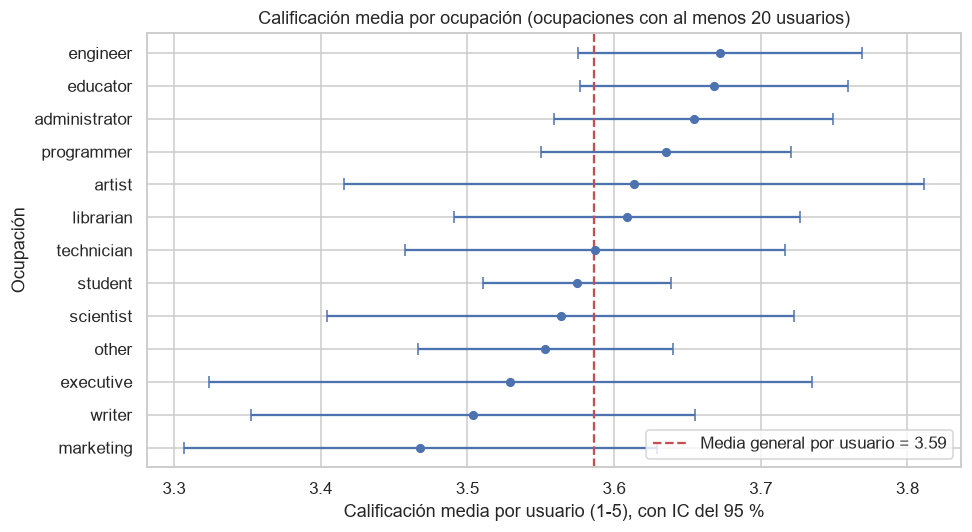

In [16]:
grafico = resumen_ocupacion.loc[ocupaciones_validas].sort_values("media")
error = np.vstack([grafico["media"] - grafico["ic_inferior"],
                   grafico["ic_superior"] - grafico["media"]])
media_global = perfil["calificacion_media"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(grafico["media"], grafico.index, xerr=error, fmt="o", color="#4C72B0",
            ecolor="#4C72B0", capsize=4, markersize=5)
ax.axvline(media_global, color="#C44E52", linestyle="--",
           label=f"Media general por usuario = {media_global:.2f}")

ax.set_xlabel("Calificación media por usuario (1-5), con IC del 95 %")
ax.set_ylabel("Ocupación")
ax.set_title("Calificación media por ocupación (ocupaciones con al menos 20 usuarios)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

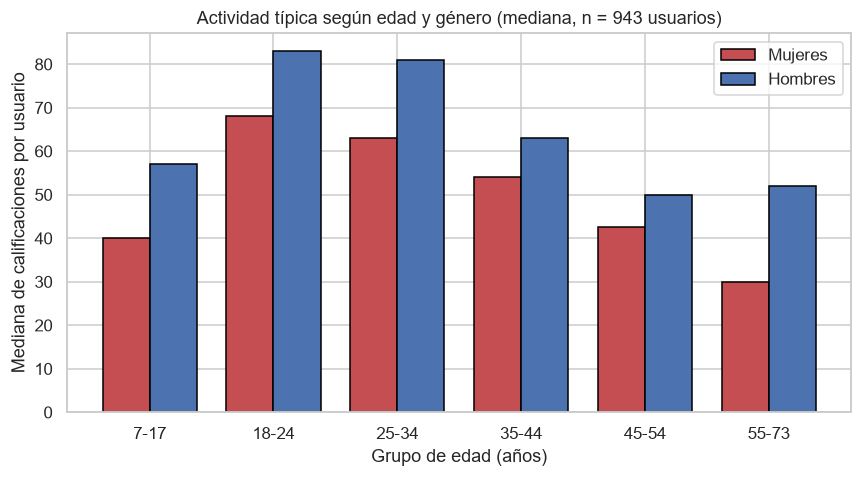

In [17]:
actividad_grupo = perfil.groupby(["grupo_edad", "gender"], observed=True)["n_calificaciones"].median().unstack()

fig, ax = plt.subplots(figsize=(8, 4.5))
posiciones = np.arange(len(actividad_grupo.index))
ancho = 0.38
ax.bar(posiciones - ancho / 2, actividad_grupo["F"], ancho, color="#C44E52",
       edgecolor="black", label="Mujeres")
ax.bar(posiciones + ancho / 2, actividad_grupo["M"], ancho, color="#4C72B0",
       edgecolor="black", label="Hombres")

ax.set_xticks(posiciones)
ax.set_xticklabels(actividad_grupo.index)
ax.set_xlabel("Grupo de edad (años)")
ax.set_ylabel("Mediana de calificaciones por usuario")
ax.set_title("Actividad típica según edad y género (mediana, n = 943 usuarios)")
ax.legend()
fig.tight_layout()
plt.show()

**Resultados:** las medias por ocupación van de 3.33 (`healthcare`, 16 usuarios) a 3.86 (`doctor`,
7 usuarios), pero las categorías extremas son justamente las de menor tamaño: el IC de `doctor` mide 0.89
puntos de ancho frente a 0.13 de `student`. Restringido a las 13 ocupaciones con n ≥ 20, Kruskal-Wallis
sobre la calificación media da **p = 0.420** (ε² = 0.000), es decir, **ninguna diferencia detectable**; en
cambio, para el número de calificaciones da p = 0.027 (ε² = 0.013).

**Conclusión:** el aparente ordenamiento de ocupaciones por generosidad al calificar **no se sostiene**:
las diferencias visibles en la tabla se explican por el ruido de las categorías pequeñas, y los IC de las
13 ocupaciones grandes se solapan casi todos con la media general. La ocupación sí muestra algún vínculo
con la actividad, aunque con un efecto muy pequeño. El último gráfico añade la lectura cruzada: las
mujeres tienen una mediana de actividad menor que los hombres en casi todos los tramos de edad, salvo el
más joven, donde el número de usuarias es demasiado pequeño para concluir nada.

**Recordatorio:** la sección 6.1 de `user.ipynb` mostró que edad y ocupación están fuertemente asociadas
(ε² = 0.395), por lo que estos dos análisis no son independientes entre sí.

## 9. Corrección por comparaciones múltiples

**Qué se calcula:** el ajuste de **Holm-Bonferroni** sobre los ocho p-valores obtenidos.

**Por qué es relevante:** al realizar ocho pruebas con α = 0.05, la probabilidad de encontrar al menos un
"hallazgo" falso por azar sube aproximadamente al 34 %. Holm controla esa tasa de error global y es menos
conservador que Bonferroni simple. Sin este paso, los resultados limítrofes serían fáciles de sobreinterpretar.

In [18]:
ajustados = holm(pruebas)
tabla_pruebas = pd.DataFrame({
    "p_original": pd.Series(pruebas),
    "p_ajustado_holm": pd.Series(ajustados),
})
tabla_pruebas["significativo_5%"] = np.where(tabla_pruebas["p_ajustado_holm"] < 0.05, "sí", "no")
tabla_pruebas.sort_values("p_original").round(5)

,p_original,p_ajustado_holm,significativo_5%
KW nº calificaciones ~ grupo de edad,0.00006,0.00049,sí
Spearman edad ~ nº calificaciones,0.00031,0.00215,sí
MW nº calificaciones ~ género,0.00243,0.01459,sí
Spearman edad ~ calificación media,0.00540,0.02702,sí
KW nº calificaciones ~ ocupación,0.02704,0.10815,no
KW calificación media ~ grupo de edad,0.03745,0.11234,no
KW calificación media ~ ocupación,0.42033,0.84065,no
MW calificación media ~ género,0.99285,0.99285,no


**Resultados:** tras el ajuste siguen siendo significativas al 5 % las cuatro pruebas relacionadas
con la **actividad** (número de calificaciones por grupo de edad, correlación edad-actividad, actividad
por género) y la correlación edad-calificación media (p ajustado 0.027). Pierden la significancia la
comparación de la calificación media entre grupos de edad (0.037 -> 0.112) y la de la actividad por
ocupación (0.027 -> 0.108).

**Conclusión:** el ajuste cambia la lectura de dos resultados que, sin corregir, parecían significativos.
Es un ejemplo directo de por qué no debe interpretarse un conjunto de p-valores como si cada prueba
hubiera sido la única realizada.

## 10. Conclusiones y limitaciones

### Conclusiones

1. **El cruce es válido:** `user_id` relaciona ambas tablas 1:N sin huérfanos; el merge conserva las
   99 455 calificaciones y los 943 usuarios, sin nulos ni duplicaciones.
2. **La actividad está muy concentrada:** mediana de 64 calificaciones por usuario, pero el 10 % más
   activo aporta el 32 % de los datos. Cualquier promedio calculado sobre las 99 455 filas describe sobre
   todo a los usuarios más activos.
3. **Lo que la demografía sí explica es *cuánto* se califica, no *qué tan alto*.** Sobreviven al ajuste de
   Holm las diferencias en actividad por edad (ε² = 0.023) y por género (mediana 54 en mujeres frente a
   69.5 en hombres, delta = -0.126), ambas con efectos pequeños.
4. **El nivel de la calificación es notablemente homogéneo:** 3.53 de media general, sin diferencia entre
   géneros (p = 0.993), sin diferencia entre ocupaciones (p = 0.420) y con una asociación con la edad
   apenas perceptible (ρ = 0.091, menos del 1 % de la variación explicada).
5. **Las diferencias descriptivas más llamativas son las menos fiables:** las ocupaciones de los extremos
   (`healthcare`, `doctor`, `homemaker`) tienen menos de 20 usuarios e intervalos de confianza hasta siete
   veces más anchos que los de `student`.

### Limitaciones

* **Muestra no probabilística:** usuarios de MovieLens entre 1997 y 1998 que se auto-seleccionaron y todos
  con al menos 19 calificaciones. Los resultados describen esta plataforma en esa época, no a la
  población general ni a los usuarios actuales de servicios de streaming.
* **Observaciones ≠ usuarios:** las 99 455 filas corresponden a 943 personas. Toda la inferencia se hizo
  sobre los 943 agregados; leer los resultados como si hubiera 99 455 sujetos independientes sería un error.
* **Sin causalidad:** el diseño es observacional. Que la edad se asocie débilmente con la calificación
  media no implica que la edad la cause; edad, género y ocupación están correlacionados entre sí y no es
  posible separar sus efectos con este análisis.
* **Sin control de las películas:** parte de la variación entre usuarios se debe a *qué* películas vio
  cada uno, información que este notebook no utiliza por diseño (corresponde a la parte `item`).
* **Categorías pequeñas:** ocho ocupaciones y el grupo etario 7-17 quedaron fuera de las pruebas o con
  intervalos muy anchos; sobre ellos solo cabe describir.
* **Escala acotada y sesgada:** las calificaciones van de 1 a 5 con moda en 4, lo que comprime las
  diferencias entre grupos y reduce la capacidad de detectarlas.